## Apple Product Price Dashboard
#### Scott Lehrfeld

In [17]:
import pandas as pd
import numpy as np
import plotly.express as px

from ipywidgets import interact, Dropdown, IntRangeSlider, interactive_output, VBox
from IPython.display import display, clear_output

In [18]:
df = pd.read_csv("apple_products_pricing_2020_2026.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.head(10)

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35
5,2020-09-26,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.29,43149.46,-1.7,NaN,In Stock,4.7,45
6,2020-09-27,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,433.06,42587.59,-0.9,NaN,In Stock,4.8,60
7,2020-09-29,Flipkart,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,429,42042,312.11,26276.64,27.2,NaN,In Stock,4.4,146
8,2020-10-01,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,323.84,31855.01,24.5,Big Billion Days,In Stock,4.7,95
9,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,390.51,38757.36,9.0,Great Indian Festival,In Stock,4.9,133


In [19]:
category_colors = {
    "iPhone": "red",
    "iPad": "blue",
    "Mac": "green",
    "Watch": "yellow"}

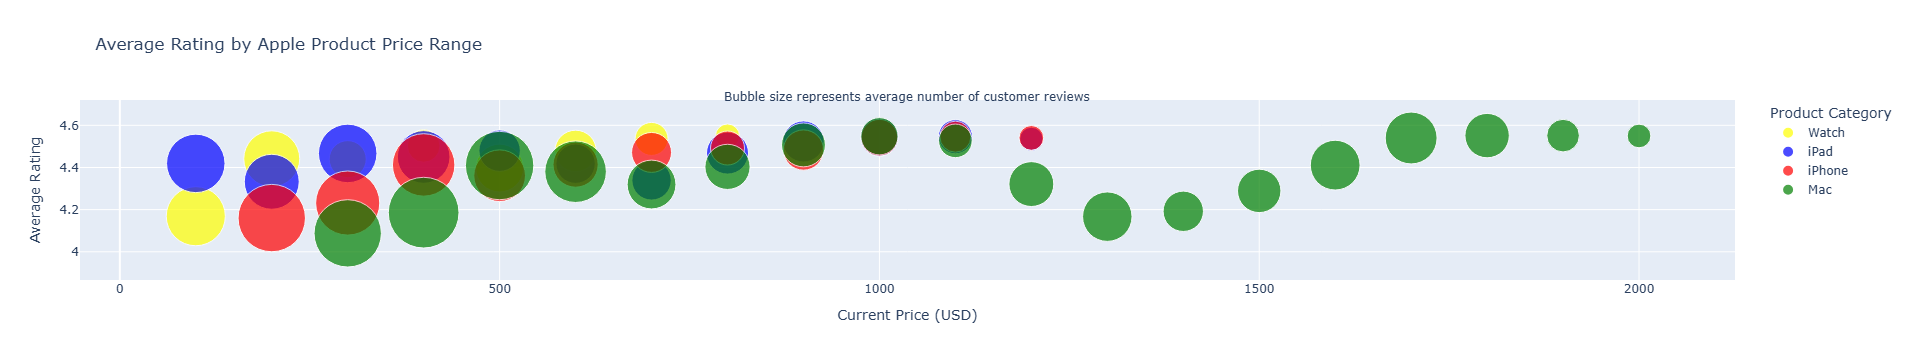

In [20]:
def create_scatter(data, title=None):
    data = data.copy()
    data["Price_Range"] = ((data["Current_Price_USD"] // 100) * 100).astype(int)

    summary = (
        data.groupby(["Price_Range", "Product_Category"], observed=True)
        .agg(Avg_Rating=("Rating", "mean"), Avg_Reviews=("Reviews_Count", "mean"), Product_Count=("Model_Name", "count"))
        .reset_index())

    summary = summary.dropna(subset=["Avg_Rating", "Avg_Reviews"])

    fig = px.scatter(
        summary,
        x="Price_Range",
        y="Avg_Rating",
        color="Product_Category",
        color_discrete_map=category_colors,
        size="Avg_Reviews",
        hover_name="Product_Category",
        hover_data={
            "Product_Count": True,
            "Avg_Reviews": ":,.0f",
            "Avg_Rating": ":.2f",
            "Price_Range": True
        },
        title=title or "Average Rating by Apple Product Price Range",
        size_max=50
    )

    fig.update_layout(
        xaxis_title="Current Price (USD)",
        yaxis_title="Average Rating",
        legend_title="Product Category"
    )

    fig.add_annotation(
        text="Bubble size represents average number of customer reviews",
        xref="paper",
        yref="paper",
        x=0.5,
        y=1.08,
        showarrow=False,
        font=dict(size=12)
    )

    fig.show()

create_scatter(df)

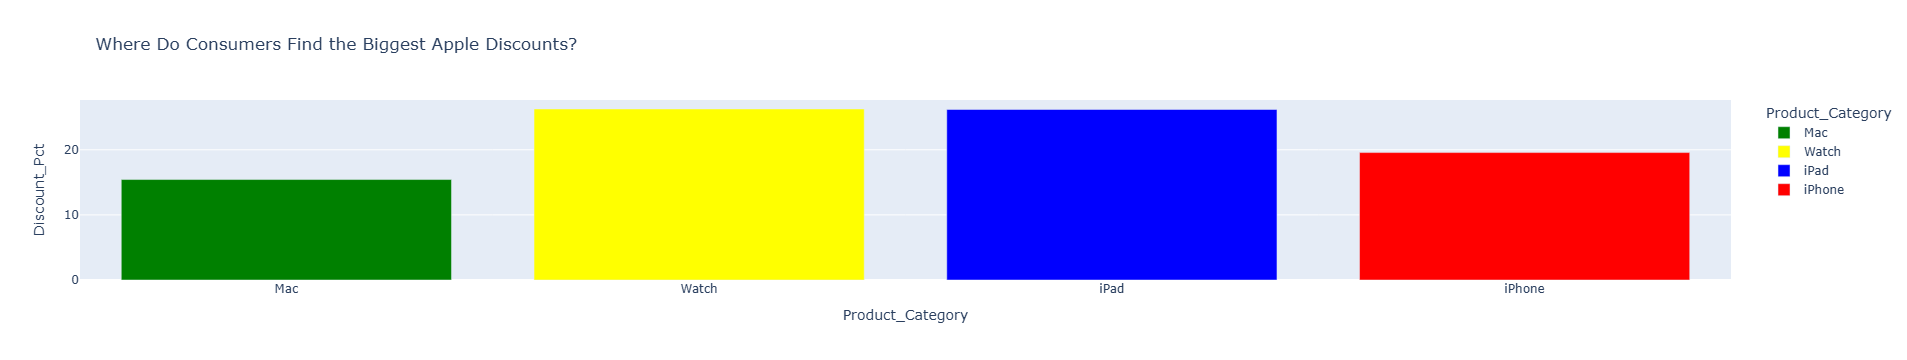

In [21]:
def create_barplot(data, title=None):
    summary = (data.groupby("Product_Category")["Discount_Pct"].mean().reset_index())

    fig = px.bar(
        summary,
        x="Product_Category",
        y="Discount_Pct",
        color="Product_Category",
        color_discrete_map=category_colors,
        title=title or "Where Do Consumers Find the Biggest Apple Discounts?"
    )
    fig.show()
create_barplot(df)

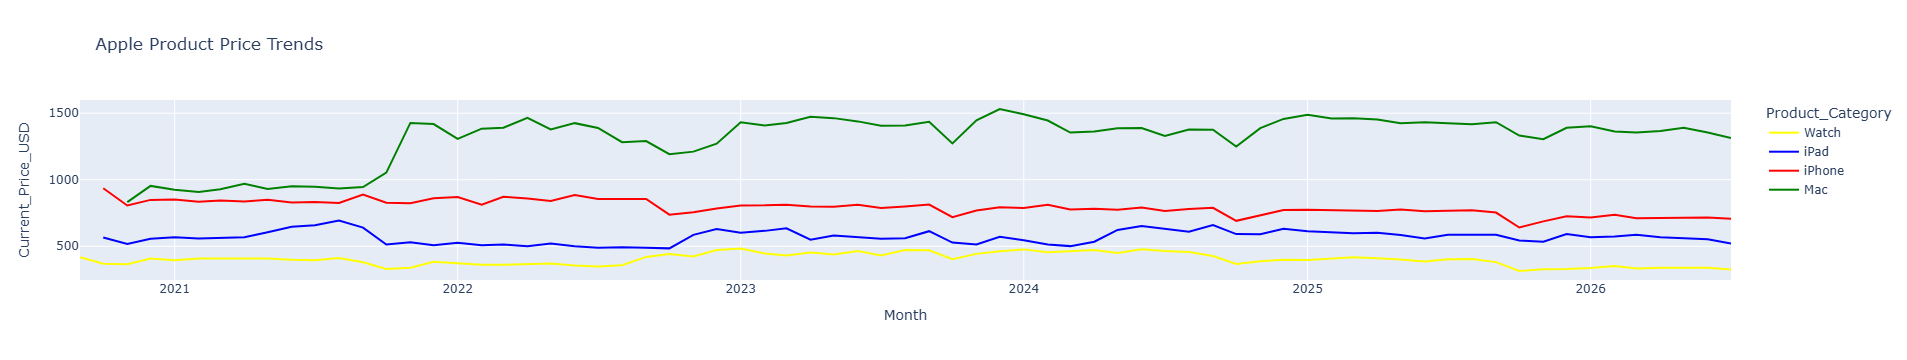

In [22]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

def create_lineplot(data, title=None):
    summary = (data.groupby(["Month", "Product_Category"])["Current_Price_USD"].mean().reset_index())
    fig = px.line(
        summary,
        x="Month",
        y="Current_Price_USD",
        color="Product_Category",
        color_discrete_map=category_colors,
        title=title or "Apple Product Price Trends"
    )
    fig.show()

create_lineplot(df)

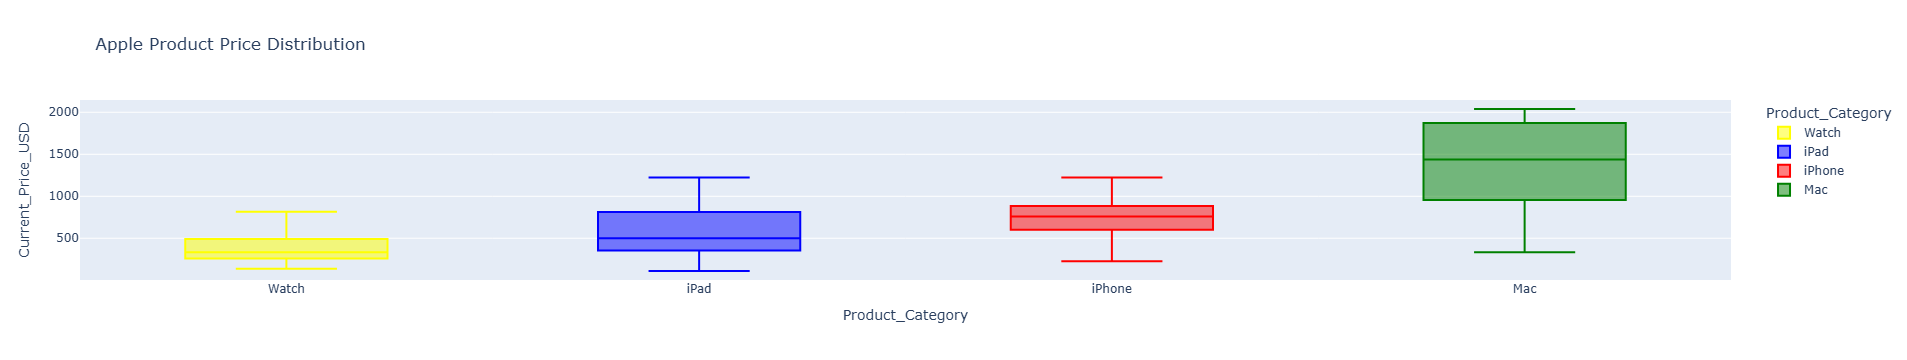

In [23]:
def create_boxplot(data, title=None):
    fig = px.box(data,
        x="Product_Category",
        y="Current_Price_USD",
        color="Product_Category",
        color_discrete_map=category_colors,
        title=title or "Apple Product Price Distribution"
    )
    fig.show()

create_boxplot(df)

In [24]:
def create_dashboard(category, platform, condition, price_range):
    filtered = df.copy()
    if category != "All":
        filtered = filtered[filtered["Product_Category"] == category]
    if platform != "All":
        filtered = filtered[filtered["Platform"] == platform]
    if condition != "All":
        filtered = filtered[filtered["Condition"] == condition]
    filtered = filtered[(filtered["Current_Price_USD"] >= price_range[0]) &(filtered["Current_Price_USD"] <= price_range[1])]

    print(f"Showing {len(filtered)} products")

    display(create_lineplot(filtered))
    display(create_barplot(filtered))
    display(create_scatter(filtered))
    display(create_boxplot(filtered))

In [30]:
category_options = (["All"] + sorted(df["Product_Category"].unique().tolist()))
platform_options = (["All"] + sorted(df["Platform"].unique().tolist()))
condition_options = (["All"] + sorted(df["Condition"].unique().tolist()))

In [26]:
category_dropdown = Dropdown(options=category_options, value="All", description="Category:")
platform_dropdown = Dropdown(options=platform_options,value="All", description="Platform:")
condition_dropdown = Dropdown(options=condition_options, value="All",description="Condition:")

In [27]:
price_slider = IntRangeSlider(
    value=(int(df["Current_Price_USD"].min()), int(df["Current_Price_USD"].max())
    ),
    min=int(df["Current_Price_USD"].min()),
    max=int(df["Current_Price_USD"].max()),
    step=50,
    description="Price:"
)

In [28]:
output = interactive_output(
    create_dashboard,
    {"category": category_dropdown, "platform": platform_dropdown, "condition": condition_dropdown, "price_range": price_slider}
)

In [29]:
display(
    VBox([
        category_dropdown,
        platform_dropdown,
        condition_dropdown,
        price_slider,
        output
    ])
)